# Fig S7 -- covariance vs correlation coordinates, and forward prediction

Two sections of the CIPHER forward-problem supplement:

- **Section A/B** (`covariance_vs_correlation_figS7_AB`): held-out single-gene forward
  prediction fit in **raw covariance** vs **standardized correlation** coordinates, for
  the real/full Sigma vs a mean-field Sigma. Three coordinate/fit variants are run
  (raw-preserving correlation-coordinate fit; ordinary correlation-space fit;
  ordinary correlation-space z-only fit).
- **Section C** (`forward_plots2_figS7_C`): the same held-out forward prediction with a
  **high-variance gene removal** filter, run at two configs
  (threshold 0.1 / quantile 0.995, and threshold 1.0 / quantile 0.9).

The shared engine lives in `notebooks/src/suppl_covcorr.py` (not part
of the cipher package). `make_gene_removal_mask` and `process_one_folder` stay inline below
because they read per-cell config globals.

**Data:** precomputed per-dataset Sigma/dx folders under
`$CIPHER_DATA_DIR/suppl/precomputed_FULL_COV_FAST_FULLLOAD_CHUNKED/` (each
`*__mean_ge_<tag>` folder holds `genes.npy`, `perturbations.npy`, `perturbation_stats.h5`,
and a `sigmas/` dir). *Verification pending that precompute tree.*


In [1]:
import os, sys
# route tqdm progress bars to text (stderr -> log) instead of un-renderable ipywidgets
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm', 'tqdm.auto', 'tqdm.notebook', 'tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception:
    pass
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "suppl" else os.getcwd())
# forward-problem engine (in notebooks/src; not part of the cipher package)
from src.suppl_covcorr import *
DATA_DIR = os.environ["CIPHER_DATA_DIR"]          # set in the sbatch script; no fallback
SUPPL = os.path.join(DATA_DIR, "suppl")
OUTDIR = os.environ.get("SUPPL_OUT", "resources/repro/figS7")
os.makedirs(OUTDIR, exist_ok=True)
from src.logutil import route_logs  # verbose logs -> .log, plots stay in-cell
route_logs("figS7_covariance_correlation")
print("data dir:", DATA_DIR)
print("suppl:   ", SUPPL)
print("outdir:  ", OUTDIR)

[logs] verbose output -> ../../resources/repro/figS7/logs/figS7_covariance_correlation.log
data dir: $CIPHER_DATA_DIR
suppl:    $SUPPL
outdir:   $SUPPL_OUT


In [2]:
import src.run_figS7 as R
import src.suppl_covcorr as C
_cfg = {k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR", "SUPPL", "OUTDIR")}
R.__dict__.update(_cfg)
C.__dict__.update(_cfg)

## Section A/B -- covariance vs correlation coordinates

Three fit variants over the same precomputed Sigma/dx folders. Each cell runs all datasets, merges per-dataset CSVs, and produces the composite histogram + dataset-median panel.

**Variant 1** -- raw-space-preserving fit in correlation coordinates (`weighted_beta_fit_corrcoords`): fit beta in z-space with sd^2 weights so the raw-space least-squares alpha is preserved exactly.

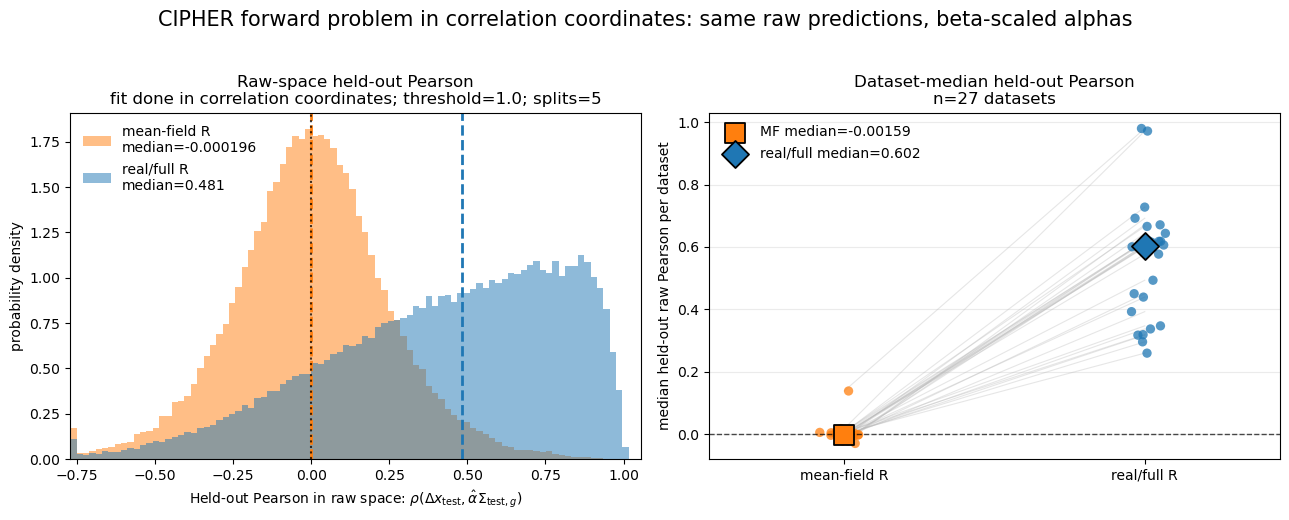

In [3]:
R.covcorr_variant1_raw_preserving()

**Variant 2** -- ordinary OLS in correlation coordinates (`ordinary_beta_fit_corrspace`): matches standardized shifts, not raw shifts; raw prediction reconstructed as `D beta R[:,g]`.

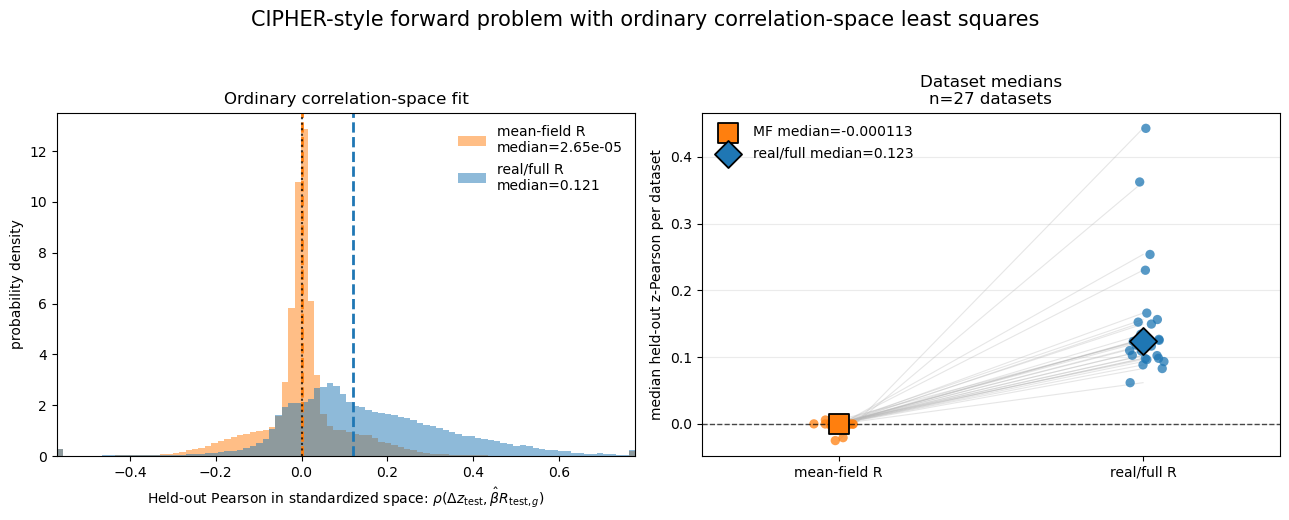

In [4]:
R.covcorr_variant2_ordinary()

**Variant 3** -- ordinary correlation-space fit evaluated in z-coordinates only (`ordinary_beta_fit_corrspace_zonly`).

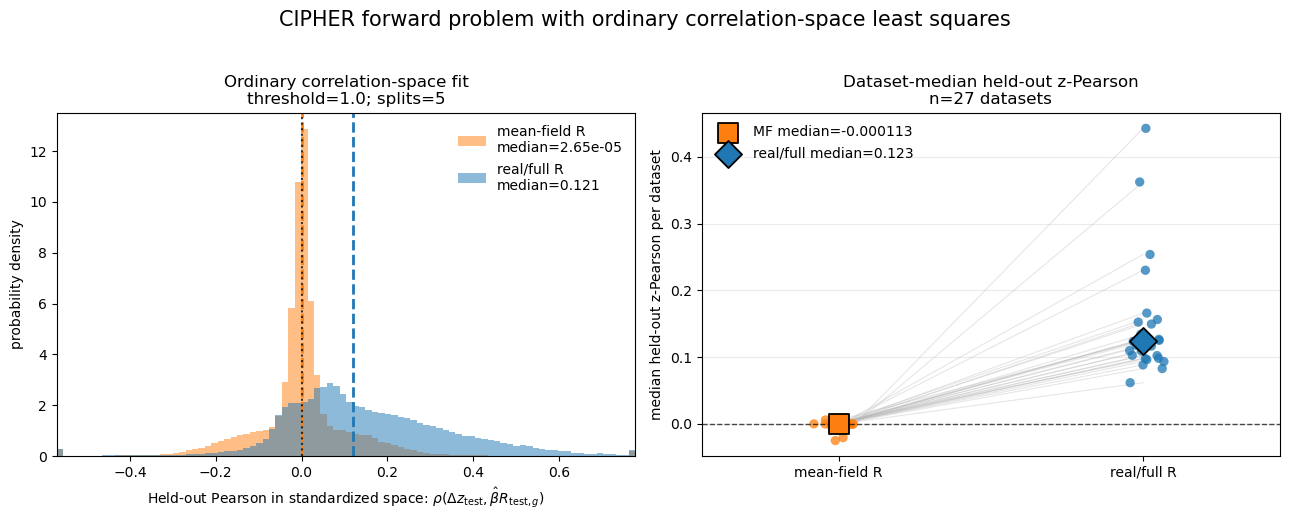

In [5]:
R.covcorr_variant3_zonly()

## Section C -- forward prediction with high-variance gene filtering

Same held-out forward prediction, but genes are removed via `make_gene_removal_mask` (explicit list + regexes + top high-variance genes). `make_gene_removal_mask` and `process_one_folder` are kept inline because they read the per-cell config globals (`EXPLICIT_REMOVE_GENES`, `HIGH_VAR_QUANTILE`, ...).

**Config 1** -- `EXPRESSION_THRESHOLD = 0.1`, `HIGH_VAR_QUANTILE = 0.995` (remove top 0.5% most variable genes).

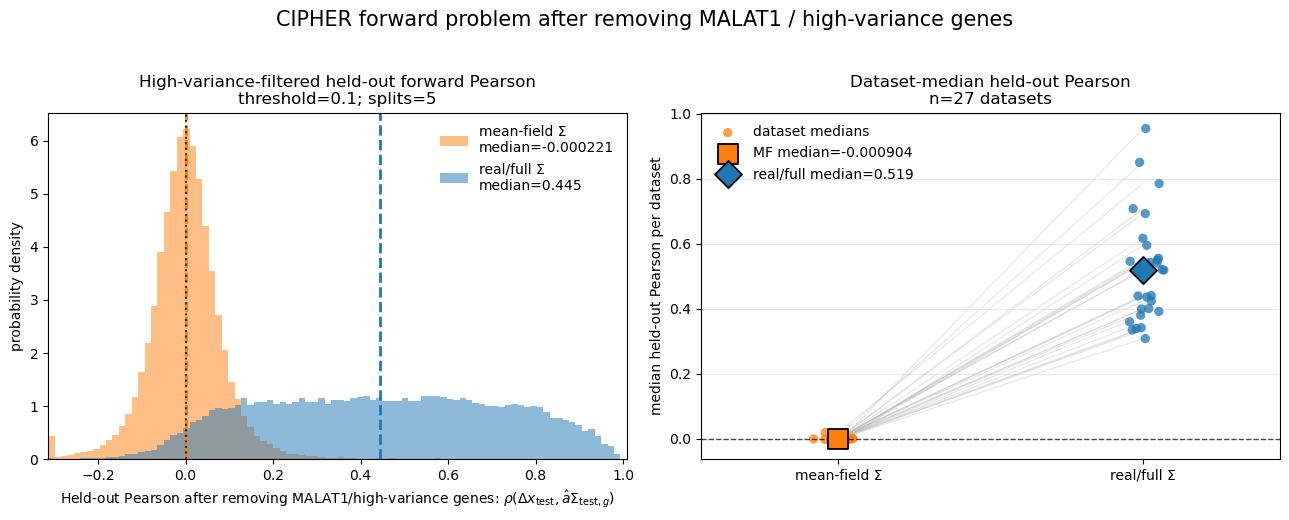

In [6]:
R.forward_highvar_config1()

**Config 2** -- `EXPRESSION_THRESHOLD = 1.0`, `HIGH_VAR_QUANTILE = 0.9` (remove top 10% most variable genes).

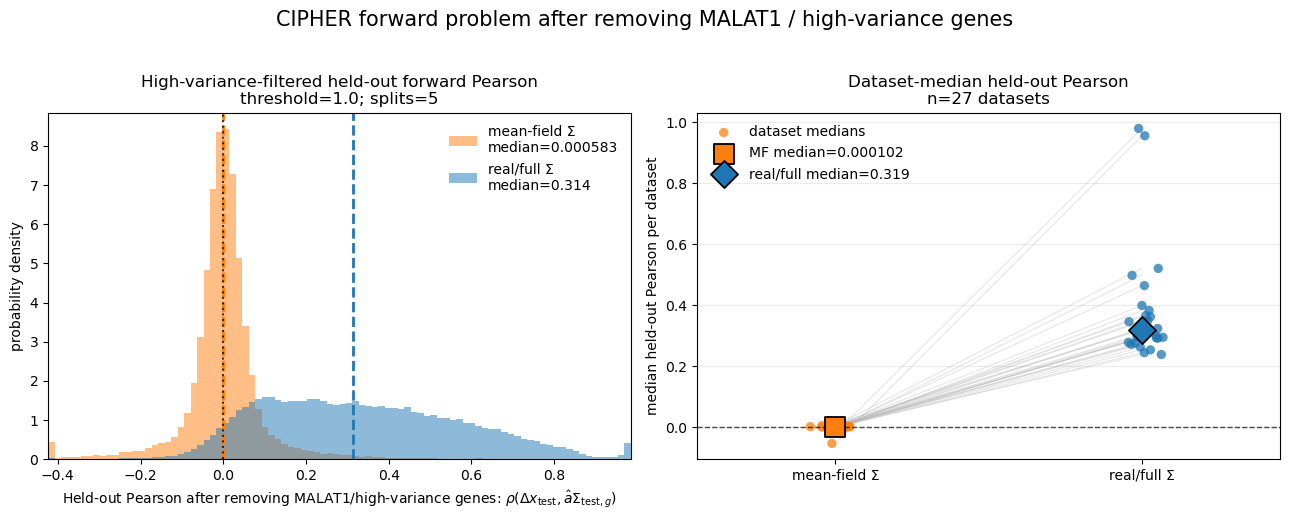

In [7]:
R.forward_highvar_config2()